In [1]:
import pandas as pd
data = pd.read_csv(r"C:\Main\Alan\Vscode\Job_predicition2\Final_Job_Data.csv")

In [2]:
data

,Degree,Specialization,CGPA,Job_Role
0,M.Tech,Textile Engineering,7.83,Production Manager
1,M.Tech,Biomedical Engineering,7.47,Equipment Technician
2,M.Sc,Statistics,6.83,Data Clerk
3,M.Sc,Electronics,9.65,Circuit Designer
4,B.Sc,Chemistry,6.05,Chemical Assistant
...,...,...,...,...
49995,B.Tech,Environmental Engineering,6.96,Waste Manager
49996,B.Tech,Mechanical Engineering,9.63,Design Engineer
49997,B.Tech,Information Technology,9.88,Cloud Architect
49998,M.Sc,Physics,8.95,Astrophysicist


In [3]:
print(data['Job_Role'].value_counts())

Job_Role
OT Manager                   669
Analytical Chemist           656
Dialysis Specialist          625
Sustainability Consultant    621
Process Design Engineer      613
                            ... 
Urban Planner                300
Design Engineer              295
Genetic Engineer             294
Senior Scientist             288
Embedded Systems Lead        288
Name: count, Length: 106, dtype: int64


In [4]:
print(data.isnull().sum())

Degree            0
Specialization    0
CGPA              0
Job_Role          0
dtype: int64


In [5]:
data = data.dropna()

In [6]:
data.head()

,Degree,Specialization,CGPA,Job_Role
0,M.Tech,Textile Engineering,7.83,Production Manager
1,M.Tech,Biomedical Engineering,7.47,Equipment Technician
2,M.Sc,Statistics,6.83,Data Clerk
3,M.Sc,Electronics,9.65,Circuit Designer
4,B.Sc,Chemistry,6.05,Chemical Assistant


In [7]:
data.tail()

,Degree,Specialization,CGPA,Job_Role
49995,B.Tech,Environmental Engineering,6.96,Waste Manager
49996,B.Tech,Mechanical Engineering,9.63,Design Engineer
49997,B.Tech,Information Technology,9.88,Cloud Architect
49998,M.Sc,Physics,8.95,Astrophysicist
49999,M.Tech,Metallurgical Engineering,6.06,Quality Control


In [8]:
from sklearn.preprocessing import LabelEncoder as ler 
le_degree = ler()
le_specialization = ler()
le_job = ler()

In [9]:
data['Degree'] = le_degree.fit_transform(data['Degree'])
data['Specialization'] = le_specialization.fit_transform(data['Specialization'])
data['Job_Role'] = le_job.fit_transform(data['Job_Role'])

In [10]:
data

,Degree,Specialization,CGPA,Job_Role
0,3,30,7.83,71
1,3,3,7.47,33
2,2,29,6.83,20
3,2,12,9.65,13
4,0,6,6.05,10
...,...,...,...,...
49995,1,14,6.96,103
49996,1,19,9.63,24
49997,1,16,9.88,14
49998,2,27,8.95,6


In [12]:
x = data[['Degree', 'Specialization', 'CGPA']]
y = data['Job_Role']

In [13]:
x

,Degree,Specialization,CGPA
0,3,30,7.83
1,3,3,7.47
2,2,29,6.83
3,2,12,9.65
4,0,6,6.05
...,...,...,...
49995,1,14,6.96
49996,1,19,9.63
49997,1,16,9.88
49998,2,27,8.95


In [14]:
y

0         71
1         33
2         20
3         13
4         10
        ... 
49995    103
49996     24
49997     14
49998      6
49999     72
Name: Job_Role, Length: 50000, dtype: int64

In [15]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42, stratify=y)

In [17]:
model = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

y_probs = model.predict_proba(x_test)
auc_score = roc_auc_score(y_test, y_probs, multi_class='ovr', average='weighted')

print(f"Model Accuracy: {accuracy * 100: .2f}%")
print(f"Multi-class AUC Score: {auc_score:.4f}")

Model Accuracy:  76.88%
Multi-class AUC Score: 0.9373


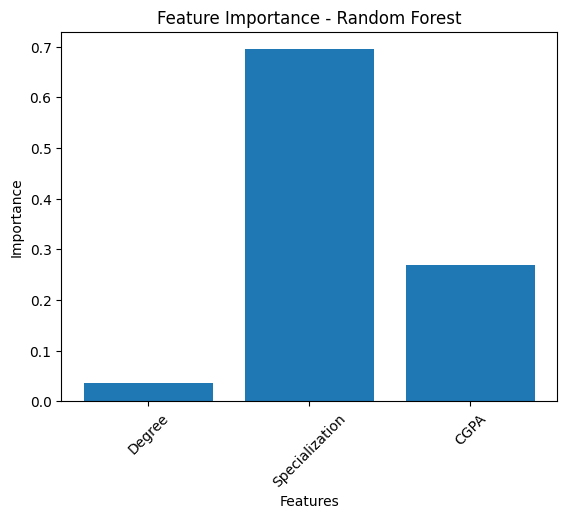

In [19]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = x.columns

plt.figure()
plt.bar(features, importances)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.xticks(rotation=45)
plt.show()

In [20]:
import joblib

joblib.dump(model, "pred_model.pkl")
joblib.dump(le_degree, "degree2.pkl")
joblib.dump(le_specialization, "specialization2.pkl")
joblib.dump(le_job, "job2.pkl")

print("Model and encoders saved successfully!")

Model and encoders saved successfully!
